In [1]:
import xarray as xr
import cmocean 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
import cartopy.crs as ccrs
import cftime
import numpy as np

In [2]:
xr.set_options(display_style='html')
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 12,6

## Assessment of Geostrophic Balance
This dataset contains:
- sea surface height (SSH --> zos) (referenced to a global mean of zero)
- zonal (u --> uo) and meridional (v --> vo) velocities 
at daily temporal resolution.


Goal is to assess the accuracy of the geostrophic balance approximation:
- step: horizontal gradient estimation (dh/dx, dh/dy --> convert lat/lon to distance) 
- step: geostrophic velocity estimation (leverage the geostrophic balance relationship to find geostrophic velocities u_g, v_g)
- step: calculate difference between surface velocities (uo,vo) and surface geostrophic velocities (difference between u and u_g, v and v_g)


Questions to address/explore:
- question 1: consider and plot differences between u_g and uo, v_g and vo as a function of timescale (e.g. using a single time slice vs. a long time mean)
- question 2: how sensitive are results to the length scale over which a gradient is calculated? (remember velocities have to be averaged across the same length scale). Choose a second length scale to compute gradient and estimate velocity difference (think of center difference methods and/or linear slope fitting)
- question 3: compute relative vorticity at a single time slice and for the time mean

In [3]:
glorys_jan_mar_2021 = xr.open_zarr('../data/glorys_jan_mar_2021_daily_surface')

In [4]:
#SOME NOTES
#NEED TO CONVERT LAT/LONG TO METERS

In [5]:
print(glorys_jan_mar_2021)
#SO IS SALINITY
#THETAO IS POTENTIAL TEMP
#UO & VO ARE OCEAN VELOCITIES
#ZOS IS SEA SURFACE HEIGHT

<xarray.Dataset>
Dimensions:    (depth: 1, latitude: 385, longitude: 950, time: 90)
Coordinates:
  * depth      (depth) float32 0.494
  * latitude   (latitude) float32 19.25 19.33 19.42 19.5 ... 51.08 51.17 51.25
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167
  * time       (time) datetime64[ns] 2021-01-01 2021-01-02 ... 2021-03-31
Data variables:
    so         (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 dask.array<chunksize=(12, 1, 97, 238), meta=np.ndarray>
    zos        (time, latitude, longitude) float32 dask.array<chunksize=(12, 97, 238), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.11
    comment:  

In [6]:
zos = glorys_jan_mar_2021.zos.isel(time=20).load()

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_5060\2400041153.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


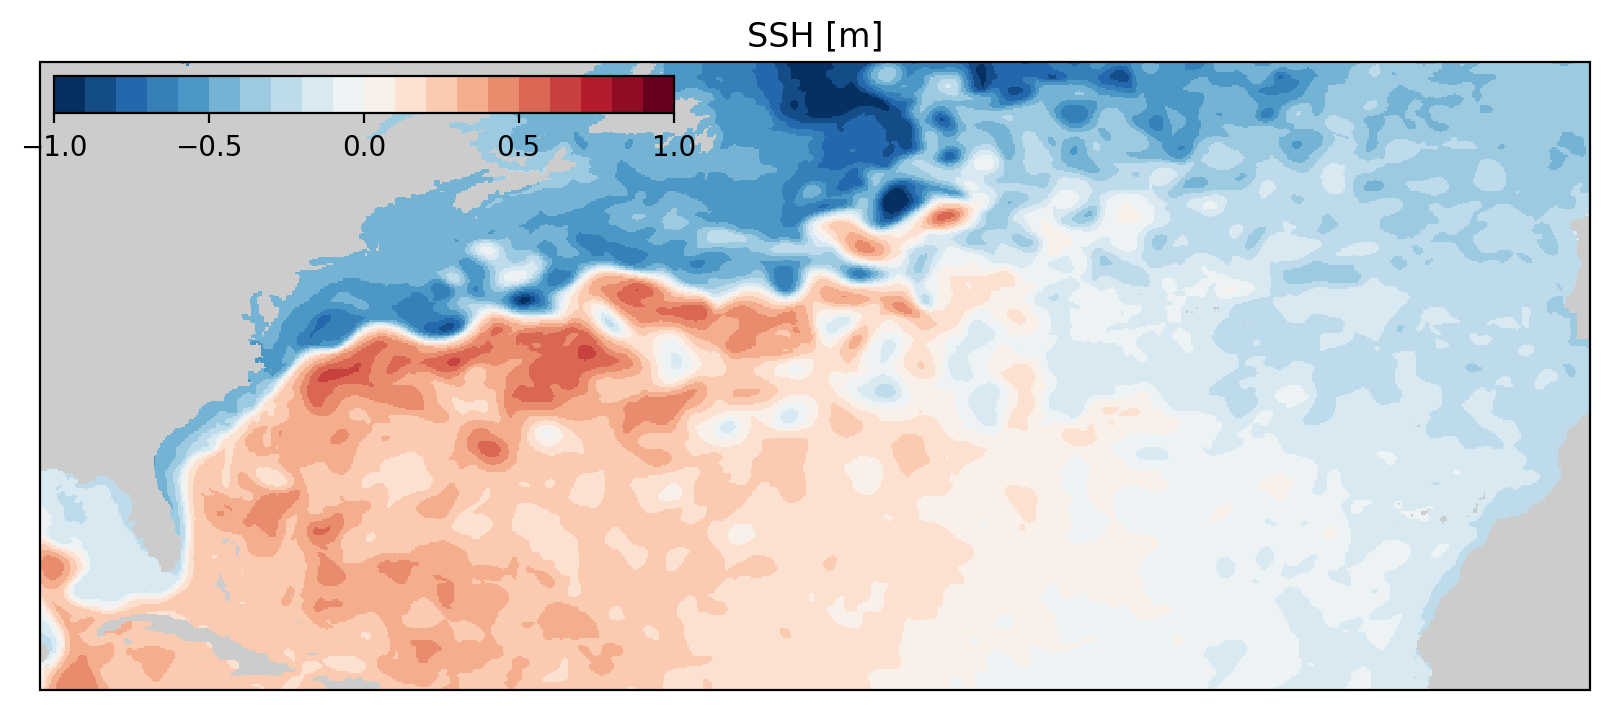

In [7]:
f, ax = plt.subplots(1,1,figsize=(10,8),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(zos.longitude, zos.latitude, zos, vmin=-1, vmax=1, \
          cmap=plt.get_cmap('RdBu_r',20),transform=ccrs.PlateCarree())
ax.set_facecolor('#cccccc')
ax.set_title('SSH [m]')
axins1 = inset_axes(ax, width="40%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

In [8]:
# sample surface velocities
ss_u = glorys_jan_mar_2021.isel(time=20).uo.isel(depth=0).load()
ss_v = glorys_jan_mar_2021.isel(time=20).vo.isel(depth=0).load()
speed = 0.5*(ss_u**2 + ss_v**2)

C:\Users\TU_Climate24_Student\AppData\Local\Temp\ipykernel_5060\4226807247.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  f.colorbar(pp, cax=axins1, orientation="horizontal")


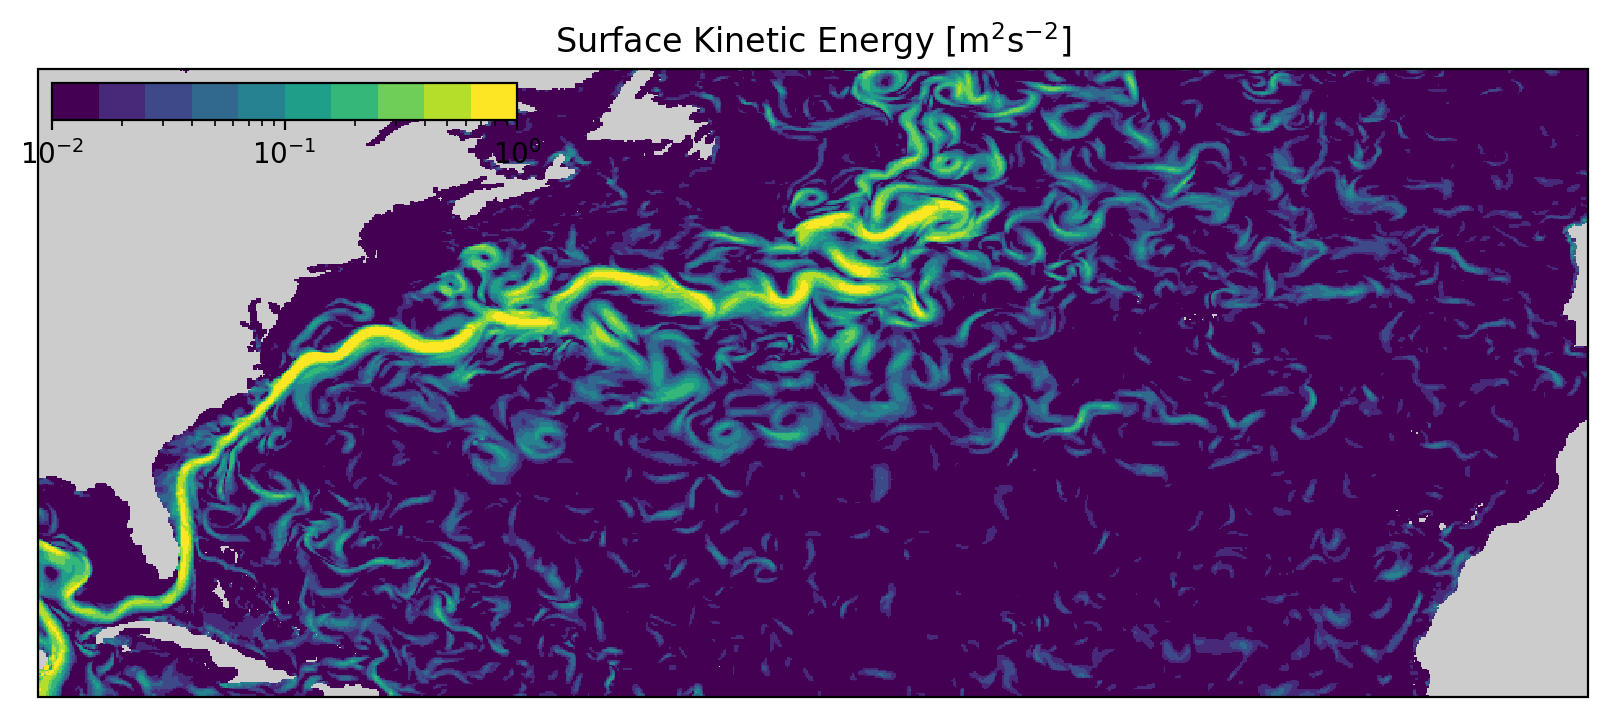

In [9]:
f, ax = plt.subplots(1,1,figsize=(10,8),subplot_kw={'projection':ccrs.PlateCarree()})
pp = ax.pcolor(ss_u.longitude, ss_u.latitude, speed, norm=LogNorm(vmin=0.01, vmax=1), \
          cmap=plt.get_cmap('viridis',10),transform=ccrs.PlateCarree())
ax.set_title(r'Surface Kinetic Energy [m$^2$s$^{-2}$]')
ax.set_facecolor('#cccccc')
axins1 = inset_axes(ax, width="30%",height="6%",loc="upper left")
ax.xaxis.set_ticks_position("top")
f.colorbar(pp, cax=axins1, orientation="horizontal")
ax.grid()

In [10]:
glorys_jan_mar_2021.isel(latitude=-1).latitude - glorys_jan_mar_2021.isel(latitude=0).latitude

<xarray.DataArray 'latitude' ()>
array(32., dtype=float32)

In [14]:
#setting some variables
ssh = glorys_jan_mar_2021.zos  # Sea Surface Height (m)
uo = glorys_jan_mar_2021.uo    # Zonal velocity (m/s) aka velocity in x
vo = glorys_jan_mar_2021.vo    # Meridional velocity (m/s) aka velocity in y

lat = glorys_jan_mar_2021.latitude
lon = glorys_jan_mar_2021.longitude
time = glorys_jan_mar_2021.time

In [18]:
#To calculate dx: dx= 1852*60*cos(lat)*(lon_n-lon_n-1)
#To calculate dy: dy=1852*60*(lat_n-lat_n-1)
#to convert degrees to radians, where i plug in a lat or long do np.deg2rad(lat)

#timescale
glorys_time_mean=glorys_jan_mar_2021.mean('time')

In [24]:
lon

<xarray.DataArray 'longitude' (longitude: 950)>
array([-87.24999 , -87.166664, -87.08333 , ...,  -8.333323,  -8.24999 ,
        -8.166656], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -87.25 -87.17 -87.08 ... -8.333 -8.25 -8.167
Attributes:
    axis:           X
    long_name:      Longitude
    standard_name:  longitude
    unit_long:      Degrees East
    units:          degrees_east

In [36]:
#dx example
dx1=1852*60*np.cos(np.deg2rad(lat.isel(latitude=10))) * (lon.isel(longitude=1)-lon.isel(longitude=0))
dx1
#this gives me the dx at a latitude of 19.3 between the first two longitudes in the data (-87.25 and -87.17)
#notice that by increasing latitude the dx value decreases. Good check

<xarray.DataArray ()>
array(8696.40694354)
Coordinates:
    latitude  float32 20.08

In [35]:
#dy example
dy1=1852*60*(lat.isel(latitude=1)-lat.isel(latitude=0))
dy1

<xarray.DataArray 'latitude' ()>
array(9260.07064819)

In [49]:
#At this point (and getting to this point, to be honest) I had a lot of help from James and Kirstin to understand how to turn this into a loop
#Was walked through a lot of this code, which I probably wouldn't have successfully produced but going through it has helped me understand whats going on
#Step one. The way I understand it, there are 2 types of arrays. Numpy and Xarray. The syntax for certain things will be different, and it is important to work in 1 array
#convert to np so that I can use np.diff and because i have already been using np.cos and np.deg2rad. This will make everything consistent
#so I am redefining my lat and lon with .values
lat = glorys_time_mean.latitude.values
lon = glorys_time_mean.longitude.values
#lat

In [50]:
#now i want to use the same equations as above but loop them so I get an array with dx and dy across the entire dataset
dx_loop = [] #initializes an empty list
for i in range (len(lat)): #for every value of latitude across the length of latitude
    dist_x = 1852 * 60 * np.cos(np.deg2rad(lat[i])) * np.diff(lon) #a lot here. This is the equation for ever lat with every difference in lon (np.diff)
    dx_loop.append(dist_x) #this adds the value just calculated to the list
dx_loop = np.array(dx_loop) #converts list to numpy array

#going to be the same process for dy
dy_loop = []
for i in range(len(lon)):
    dist_y= 1852 * 60 * np.diff(lat)
    dy_loop.append(dist_y)
dy_loop = np.array(dy_loop)

In [62]:
#dy_loop.shape
#dx_loop.shape
#checking the shape for each new array reveals that they do not match the shape of the original data (care about ssh)
#this is because the way this loop took a difference, it eventually runs out of data to take a difference with
#so the solution is to trim the ssh data to match these new shapes
shrunk_array= np.array(glorys_time_mean.zos.isel(latitude=slice(0,-1)).isel(longitude=slice(0,-1)))
shrunk_array.shape
#boom
#i think i need to do this for zos itself too
shrunk_ssh_array= np.array(zos.isel(latitude=slice(0,-1)).isel(longitude=slice(0,-1)))
shrunk_ssh_array

array([[ 0.07263406,  0.13000885,  0.17365032, ...,         nan,
                nan,         nan],
       [ 0.06012146,  0.11749626,  0.16296884, ...,         nan,
                nan,         nan],
       [ 0.05279702,  0.10711997,  0.1535081 , ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ..., -0.39002654,
        -0.39033175, -0.39063692],
       [        nan,         nan,         nan, ..., -0.39002654,
        -0.3909421 , -0.39185765],
       [        nan,         nan,         nan, ..., -0.3930784 ,
        -0.39368877, -0.39429915]], dtype=float32)

In [63]:
#i want to get the ssh/distance gradients
#dh/dx
#need a variable for dh, which is change in shh 
ssh_lat = zos.diff('latitude').values
ssh_lon = zos.diff('longitude').values

In [66]:
ssh_lon.shape

(385, 949)

In [74]:
#ssh/distance gradients
dhdx=ssh_lon/dx_loop
dhdy=ssh_lat/dy_loop.T #the arrays didnt match, .T transponds it

array([[ 6.56332168e-06,  4.99185853e-06,  4.78240781e-06, ...,
                    nan,             nan,             nan],
       [ 6.56666407e-06,  5.20395497e-06,  4.81976940e-06, ...,
                    nan,             nan,             nan],
       [ 6.22055541e-06,  5.31144724e-06,  4.78729271e-06, ...,
                    nan,             nan,             nan],
       ...,
       [            nan,             nan,             nan, ...,
        -1.57393032e-07, -1.57393032e-07, -2.09853283e-07],
       [            nan,             nan,             nan, ...,
        -1.05119874e-07, -1.05119874e-07, -1.57675444e-07],
       [            nan,             nan,             nan, ...,
        -5.26577004e-08, -5.26525596e-08,  0.00000000e+00]], dtype=float32)

In [79]:
#i want to use these to calculate velocities
#variables
g=9.81 #(m/s^2)
omega = 7.2921e-5 #(rad/s) (rotation rate)
#Geostrophic velocities
#ug = -(g/f)*dh/dy
#vg = (g/f)*dh/dx
#for the sake of simplicify i will assume that f= 1x10e-4 or 0.0001
f = 0.0001
ug_calc = -(g/f)*dhdy
vg_calc = (g/f)*dhdx

In [89]:
#i want these back in xarray because thats how I know how to plot things...
ug_calc_x = xr.DataArray(ug_calc)
vg_calc_x = xr.DataArray(vg_calc)
ug_calc_x

<xarray.DataArray (dim_0: 384, dim_1: 950)>
array([[0.13255682, 0.13255674, 0.11315823, ...,        nan,        nan,
               nan],
       [0.07759598, 0.1099276 , 0.10022824, ...,        nan,        nan,
               nan],
       [0.08729346, 0.1260906 , 0.10992508, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ..., 0.00646613, 0.01293258,
        0.01939872],
       [       nan,        nan,        nan, ..., 0.02909722, 0.0258643 ,
        0.02263138],
       [       nan,        nan,        nan, ..., 0.0581971 , 0.05496372,
        0.0452642 ]])
Dimensions without coordinates: dim_0, dim_1

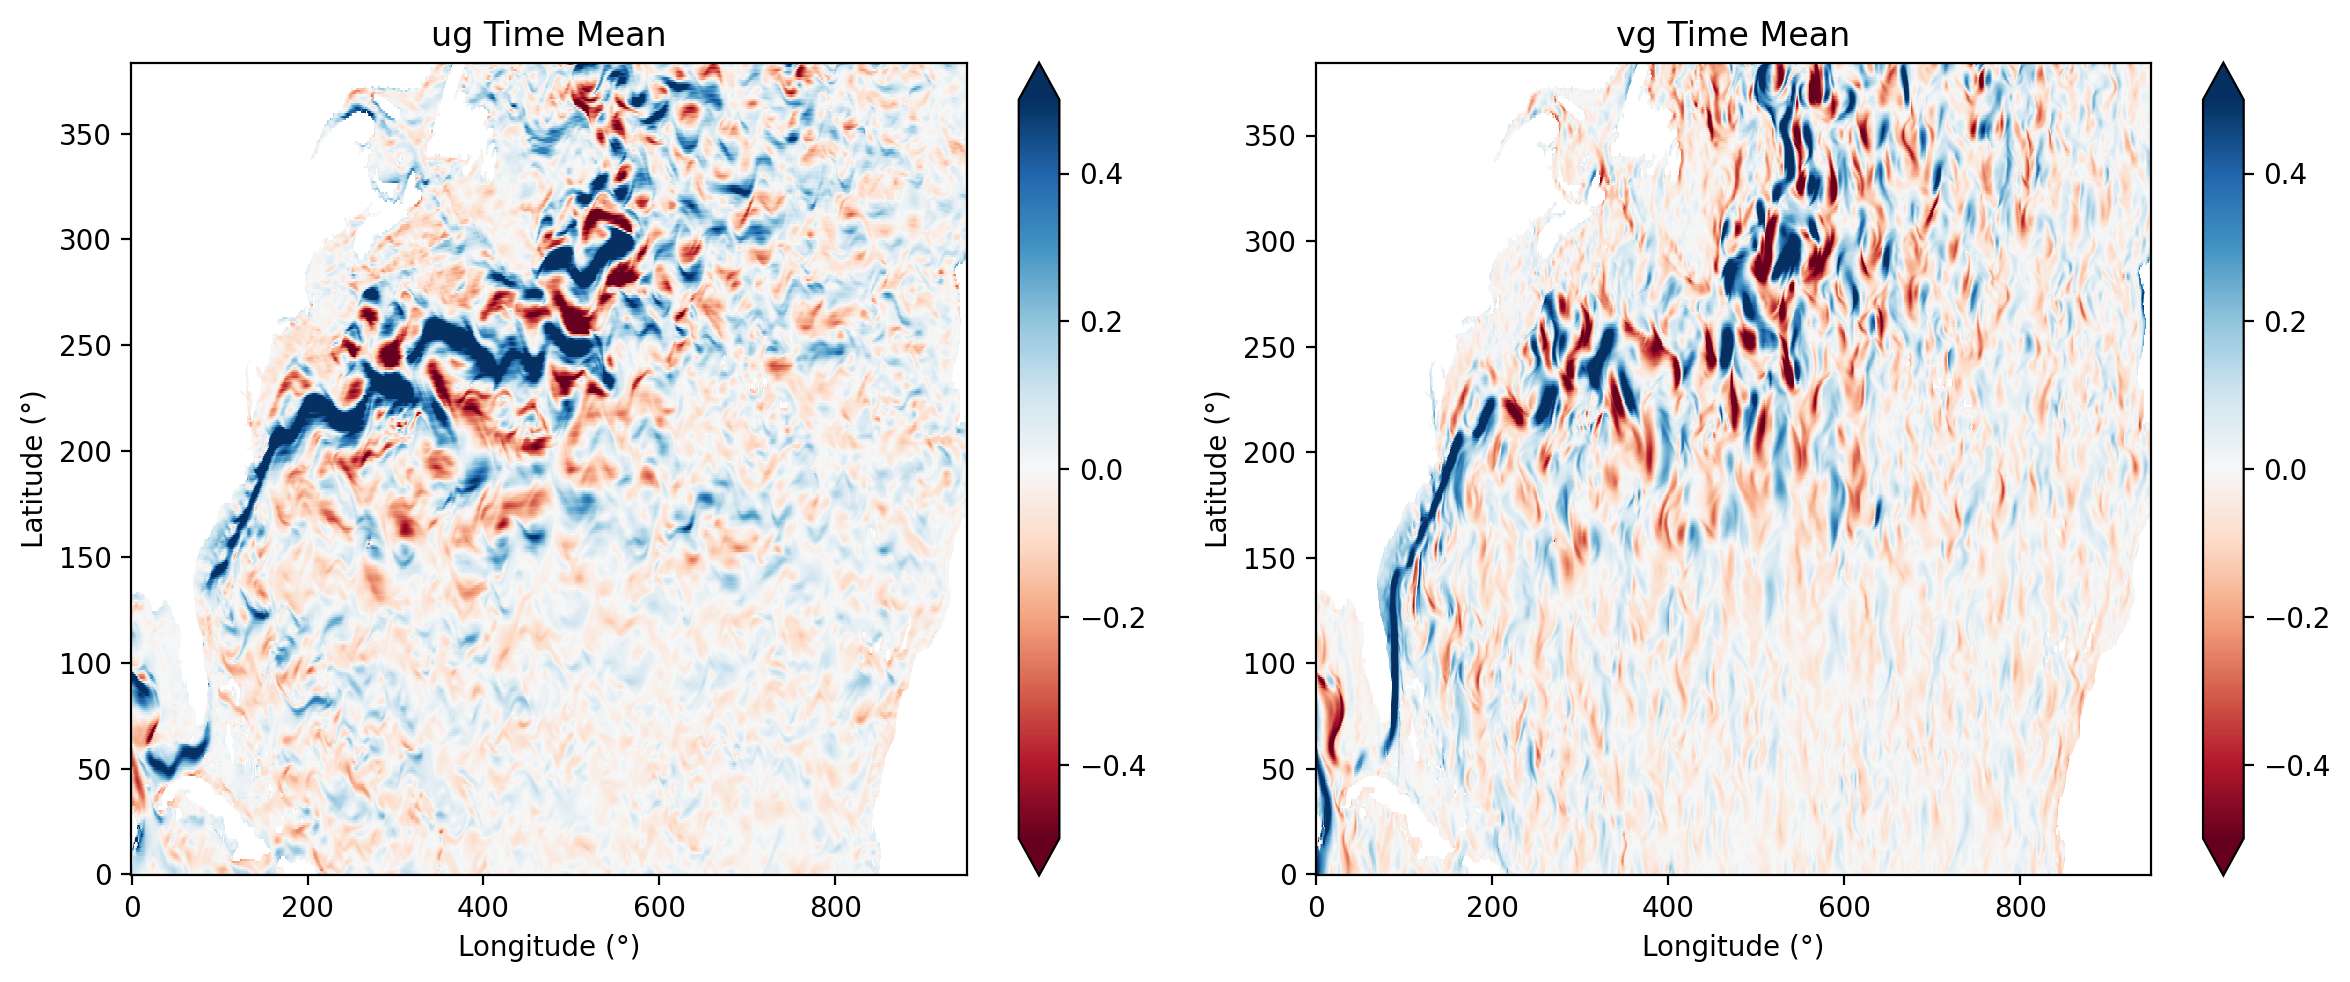

In [91]:
fig, ax = plt.subplots(1,2, figsize = (12,5))
ug_calc_x.plot(ax=ax[0], cmap='RdBu', vmin=-0.5, vmax=0.5)
ax[0].set_title('ug Time Mean')
ax[0].set_ylabel('Latitude (°)')
ax[0].set_xlabel('Longitude (°)')
vg_calc_x.plot(ax=ax[1], cmap='RdBu', vmin=-0.5, vmax=0.5)
ax[1].set_title('vg Time Mean')
ax[1].set_ylabel('Latitude (°)')
ax[1].set_xlabel('Longitude (°)')
plt.tight_layout()
plt.show()

## This feels like a win

In [102]:
#if i want to compare this to a specific time i need to redo a lot of this I think
#time goes by days. So i can pick a day with the isel thing?
#time.isel(time=7) #gives jan 8 2021
glorys_time_day8=glorys_jan_mar_2021.isel(time=7)
#glorys_time_day8 #now I have a variable like the mean that will give me the good stuff for that date
lat8 = glorys_time_day8.latitude.values
lon8 = glorys_time_day8.longitude.values
#keep redefining variables for this specific day
dx_loop8 = [] #initializes an empty list
for i in range (len(lat8)): #for every value of latitude across the length of latitude
    dist_x8 = 1852 * 60 * np.cos(np.deg2rad(lat8[i])) * np.diff(lon8) #a lot here. This is the equation for ever lat with every difference in lon (np.diff)
    dx_loop8.append(dist_x8) #this adds the value just calculated to the list
dx_loop8 = np.array(dx_loop8) #converts list to numpy array

#going to be the same process for dy
dy_loop8 = []
for i in range(len(lon8)):
    dist_y8= 1852 * 60 * np.diff(lat8)
    dy_loop8.append(dist_y8)
dy_loop8 = np.array(dy_loop8)

#ssh/distance gradients
dhdx8=ssh_lon/dx_loop8
dhdy8=ssh_lat/dy_loop8.T

ug_calc8 = -(g/f)*dhdy8
vg_calc8 = (g/f)*dhdx8

ug_calc8_x = xr.DataArray(ug_calc8)
vg_calc8_x = xr.DataArray(vg_calc8)

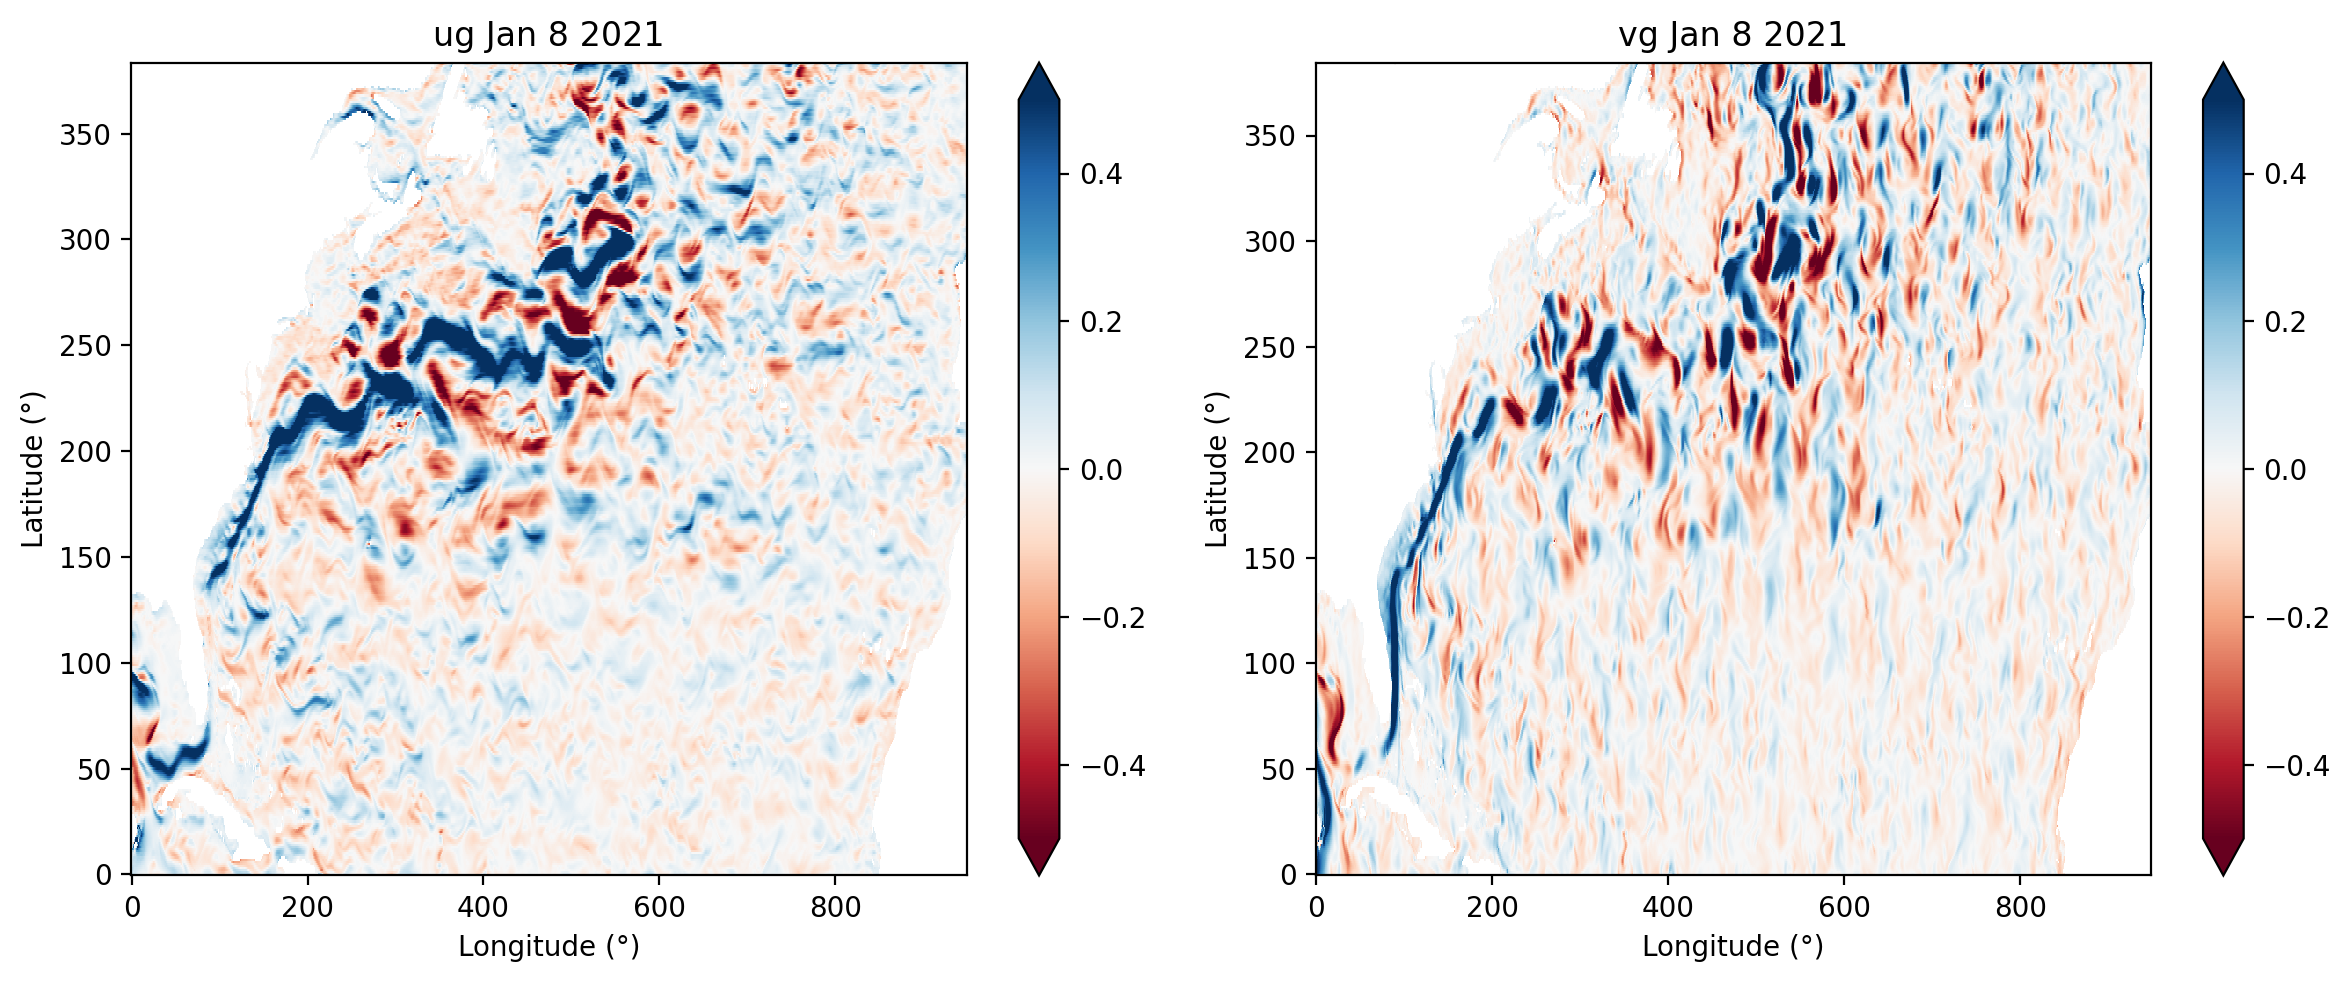

In [103]:
fig, ax = plt.subplots(1,2, figsize = (12,5))
ug_calc8_x.plot(ax=ax[0], cmap='RdBu', vmin=-0.5, vmax=0.5)
ax[0].set_title('ug Jan 8 2021')
ax[0].set_ylabel('Latitude (°)')
ax[0].set_xlabel('Longitude (°)')
vg_calc8_x.plot(ax=ax[1], cmap='RdBu', vmin=-0.5, vmax=0.5)
ax[1].set_title('vg Jan 8 2021')
ax[1].set_ylabel('Latitude (°)')
ax[1].set_xlabel('Longitude (°)')
plt.tight_layout()
plt.show()

## Q1: I Dont see a lot of difference when comparing between time scales... I assume that the day to day velocities will vary (might be more obvious if I looked at a lot of different days) but never too far from the mean. I take this to mean that geostrophic velocities are consistent on large time scales.

## Q2
### conceptually I understand this one (I think) but I dont really know where to start with changing my code to plot this. 
### based on the geostrophic velocity equations, an increase in the change in distance (greater dx or dx) with all else held constant would result in a lower velocity
### An increase in the change in ssh (dh) would have the opposite effect, and would increase velocity
### having a large length scale is important for accuracy though, since local variations may be exaggerated 

### Everything below here is an attempt that I'm moving on from, didn't seem like it was going anywhere

In [12]:
#I dont like this as much as my code below

#computing distance in meters
#R = 6371000  # Earth radius in meters
#phi = np.deg2rad(lat)

# Meridional distance (dy) - spacing in y-direction (latitude)
#dy = np.gradient(lat) * np.pi/180 * R  # 1D array

# Zonal distance (dx) - spacing in x-direction (longitude), depends on latitude
#dx = np.gradient(lon) * np.pi/180 * R * np.cos(phi[:, np.newaxis])  # 2D array

In [13]:
#sea surface height gradients
# Central difference approximation
dh_dy = np.gradient(ssh, axis=1) / dy[np.newaxis, :, np.newaxis]  # ∂h/∂y
dh_dx = np.gradient(ssh, axis=2) / dx[np.newaxis, :, :]            # ∂h/∂x

NameError: name 'dy' is not defined

In [ ]:
#calculating geostrophic velocities
g = 9.81             # gravity (m/s^2)
omega = 7.2921e-5    # Earth's rotation rate (rad/s)
f = 2 * omega * np.sin(phi)          # Coriolis parameter (1D array)
f_2d = f[np.newaxis, :, np.newaxis]  # broadcast to (time, lat, lon)

# Geostrophic velocities
ug = - g / f_2d * dh_dy  # u_g = - g/f * ∂h/∂y
vg = g / f_2d * dh_dx    # v_g = g/f * ∂h/∂x

#and differences with actual velocities
delta_u = uo - ug
delta_v = vo - vg

#and single day vs mean
delta_u_day1 = delta_u.isel(time=0)
delta_v_day1 = delta_v.isel(time=0)

delta_u_mean = delta_u.mean(dim='time')
delta_v_mean = delta_v.mean(dim='time')


In [15]:
help="i have no idea what is going on"
print(help)


i have no idea what is going on


In [ ]:
#asked chat gpt to help me modify some code from Becki's notebook to convert lat/lon to m
def latlon_to_meters(dlat_deg, dlon_deg, lat_deg, rE=6371.0e3):
    """Converts a given change in latitude/longitude (degrees)
       to distance in meters at a given latitude."""
    dlat_rad = np.radians(dlat_deg)
    dlon_rad = np.radians(dlon_deg)
    lat_rad = np.radians(lat_deg)

    dy = rE * dlat_rad               # N–S distance
    dx = rE * np.cos(lat_rad) * dlon_rad  # E–W distance

    return dx, dy

In [ ]:
#example
#dx output gives change in longitudinal direction
#dy output gives change in latitudinal direction
dx, dy = latlon_to_meters(0, 1, 45)  # 1° longitude at 45°N
print(dx, dy)


In [ ]:
#now i will compute grid spacings in meters for lat and lon
#i have my coordinate arrays named lat and lon

# Compute differences in degrees (assuming regular grid)
dlat = lat[1] - lat[0]
dlon = lon[1] - lon[0]

# Compute dx, dy arrays (2D)
lat2d, lon2d = np.meshgrid(lat, lon, indexing='ij')
dx, dy = latlon_to_meters(dlat, dlon, lat2d)

#this gives us dx, which is east-west (longitudeinal distance)
#and dy, north-south (latitudinal distance)